<a href="https://colab.research.google.com/github/jahnavi-kallu/Message/blob/main/HAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ACTIVITY_NAMES = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

In [16]:
# Install required libraries (Google Colab only)
!pip install scikit-learn pandas numpy requests matplotlib seaborn joblib --quiet

# Import required libraries
import io
import time
import zipfile
import warnings

warnings.filterwarnings("ignore")   # Hide unnecessary warning messages

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import requests

# Machine Learning libraries
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Improve graph appearance
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Activity labels in the dataset
ACTIVITY_NAMES = {
    0: "Walking",
    1: "Walking Upstairs",
    2: "Walking Downstairs",
    3: "Sitting",
    4: "Standing",
    5: "Laying"
}

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Download the UCI HAR dataset
url = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
response = requests.get(url)
response.raise_for_status()

# Extract the dataset
with zipfile.ZipFile(io.BytesIO(response.content)) as outer_zip:
    inner_data = outer_zip.read("UCI HAR Dataset.zip")

with zipfile.ZipFile(io.BytesIO(inner_data)) as dataset:
    X = pd.read_csv(
        dataset.open("UCI HAR Dataset/train/X_train.txt"),
        sep=r"\s+",
        header=None
    )

    y = pd.read_csv(
        dataset.open("UCI HAR Dataset/train/y_train.txt"),
        sep=r"\s+",
        header=None
    ).values.ravel()

print("Dataset loaded successfully!")
print("Samples :", X.shape[0])
print("Features:", X.shape[1])
print("Classes :", len(np.unique(y)))

Dataset loaded successfully!
Samples : 7352
Features: 561
Classes : 6


In [3]:
# Scale the feature values
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Convert activity labels into numbers (0–5)
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Preprocessing completed!")
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Preprocessing completed!
Training samples: 5881
Testing samples : 1471


In [21]:
# Train the baseline model using all 561 features
model = GaussianNB()

# Measure training time
start = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Display results
print("Baseline Model (561 Features)")
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Training Time:", round(training_time, 4), "seconds")

# Detailed performance report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Baseline Model (561 Features)
Accuracy: 75.87 %
Training Time: 0.0401 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.74      0.82       245
           1       0.70      0.91      0.79       215
           2       0.81      0.82      0.82       197
           3       0.57      0.53      0.55       257
           4       0.69      0.93      0.79       275
           5       0.97      0.67      0.79       282

    accuracy                           0.76      1471
   macro avg       0.78      0.76      0.76      1471
weighted avg       0.78      0.76      0.76      1471



In [6]:
# Number of features to select
n_clusters = 50

# Apply K-Means clustering on features
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
kmeans.fit(X.T)      # Transpose so features become data points

# Select one representative feature from each cluster
selected_features = []

for i in range(n_clusters):
    cluster_features = np.where(kmeans.labels_ == i)[0]
    center = kmeans.cluster_centers_[i]

    distances = np.linalg.norm(X.T[cluster_features] - center, axis=1)
    best_feature = cluster_features[np.argmin(distances)]

    selected_features.append(best_feature)

# Create dataset with selected features
X_reduced = X[:, selected_features]

# Split reduced dataset
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Feature Selection Completed!")
print("Original Features :", X.shape[1])
print("Selected Features :", len(selected_features))

Feature Selection Completed!
Original Features : 561
Selected Features : 50


In [19]:
# Train the model using the selected 50 features
reduced_model = GaussianNB()

# Measure training time
start = time.time()
reduced_model.fit(X_train_reduced, y_train)
reduced_training_time = time.time() - start

# Make predictions
y_pred_reduced = reduced_model.predict(X_test_reduced)

# Calculate accuracy
reduced_accuracy = accuracy_score(y_test, y_pred_reduced)

# Display results
print("K-Means Feature Selection Model (50 Features)")
print("Accuracy:", round(reduced_accuracy * 100, 2), "%")
print("Training Time:", round(reduced_training_time, 4), "seconds")

# Detailed performance report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_reduced))

K-Means Feature Selection Model (50 Features)
Accuracy: 87.7 %
Training Time: 0.0089 seconds

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       245
           1       0.77      0.92      0.84       215
           2       0.84      0.83      0.84       197
           3       0.91      0.75      0.83       257
           4       0.82      0.91      0.86       275
           5       0.98      0.99      0.99       282

    accuracy                           0.88      1471
   macro avg       0.88      0.87      0.87      1471
weighted avg       0.88      0.88      0.88      1471



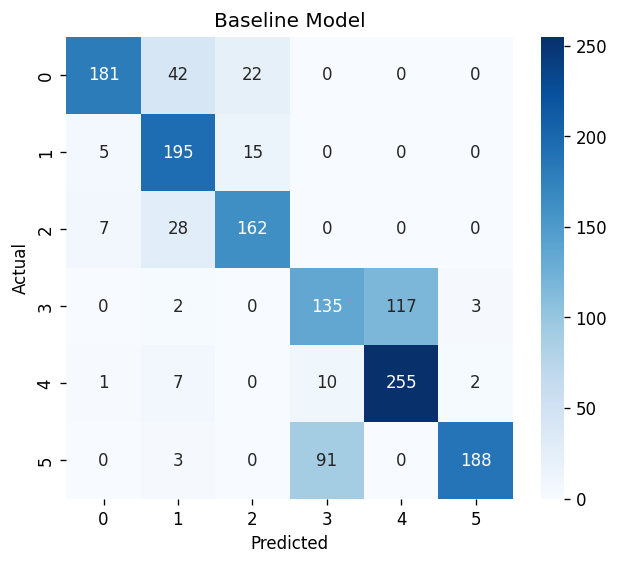

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Baseline Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


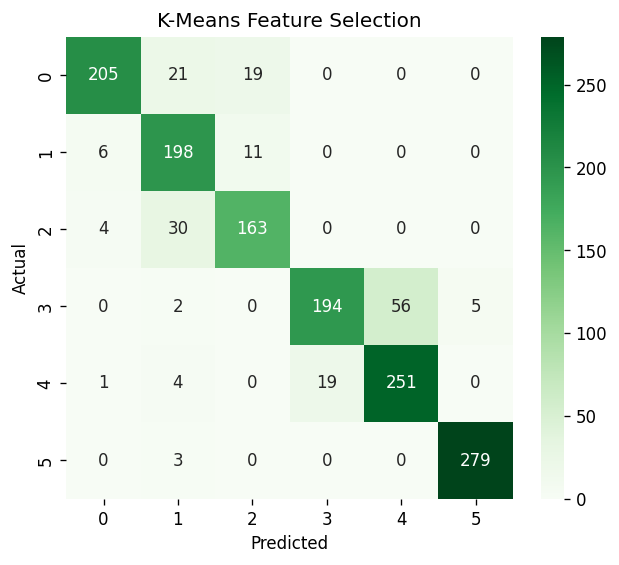

In [13]:
cm = confusion_matrix(y_test, y_pred_reduced)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("K-Means Feature Selection")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

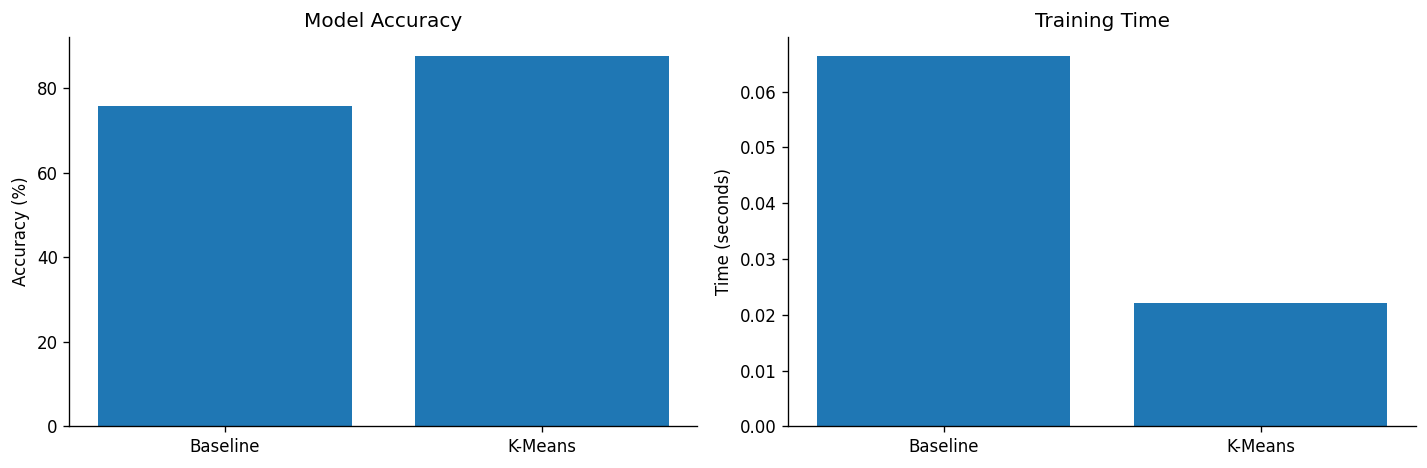

In [15]:
# Compare the two models

models = ["Baseline", "K-Means"]
accuracy = [accuracy * 100, reduced_accuracy * 100]
training_time = [training_time, reduced_training_time]

plt.figure(figsize=(12, 4))

# Accuracy comparison
plt.subplot(1, 2, 1)
plt.bar(models, accuracy)
plt.title("Model Accuracy")
plt.ylabel("Accuracy (%)")

# Training time comparison
plt.subplot(1, 2, 2)
plt.bar(models, training_time)
plt.title("Training Time")
plt.ylabel("Time (seconds)")

plt.tight_layout()
plt.show()